In [19]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [20]:
cwd = Path.cwd().resolve()
BASE_DIR = cwd.parent if cwd.name == "notebooks" else cwd


fleet_path = (BASE_DIR / "data" / "synthetic"/"fleet_rotary_blower_Finaldataset_2025.csv")
fleet_df = pd.read_csv(fleet_path)
fleet_df["date"] = pd.to_datetime(fleet_df["date"])
fleet_df.head()
fleet_df.info()
fleet_df.describe()
fleet_df.isna().sum()
fleet_df["maintenance_event"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   4380 non-null   datetime64[us]
 1   amb_temp_max_c         4380 non-null   float64       
 2   amb_temp_min_c         4380 non-null   float64       
 3   amb_temp_avg_c         4380 non-null   float64       
 4   humidity               4380 non-null   float64       
 5   wind_gust_kph          4380 non-null   float64       
 6   blower_id              4380 non-null   str           
 7   site_id                4380 non-null   str           
 8   operational_class      4380 non-null   str           
 9   max_op_ambient_temp_c  4380 non-null   float64       
 10  failure_threshold      4380 non-null   float64       
 11  max_op_rpm             4380 non-null   int64         
 12  daily_op_hours         4380 non-null   float64       
 13  cumulative_op_

maintenance_event
0    4360
1      20
Name: count, dtype: int64

In [21]:
fleet_df.groupby("blower_id")["maintenance_event"].sum()


blower_id
ZG150_B001    2
ZG150_B002    2
ZG150_B003    2
ZG150_B004    2
ZG200_B011    2
ZG200_B012    1
ZG200_B013    2
ZG200_B014    1
ZG250_B021    2
ZG250_B022    1
ZG250_B023    2
ZG250_B024    1
Name: maintenance_event, dtype: int64

In [22]:
fleet_df.groupby("blower_id")["degradation_index"].max()

blower_id
ZG150_B001    0.699040
ZG150_B002    0.698616
ZG150_B003    0.698042
ZG150_B004    0.698428
ZG200_B011    0.698971
ZG200_B012    0.699422
ZG200_B013    0.699761
ZG200_B014    0.699380
ZG250_B021    0.699622
ZG250_B022    0.699862
ZG250_B023    0.699835
ZG250_B024    0.696747
Name: degradation_index, dtype: float64

DISTRIBUTION ANALYSIS

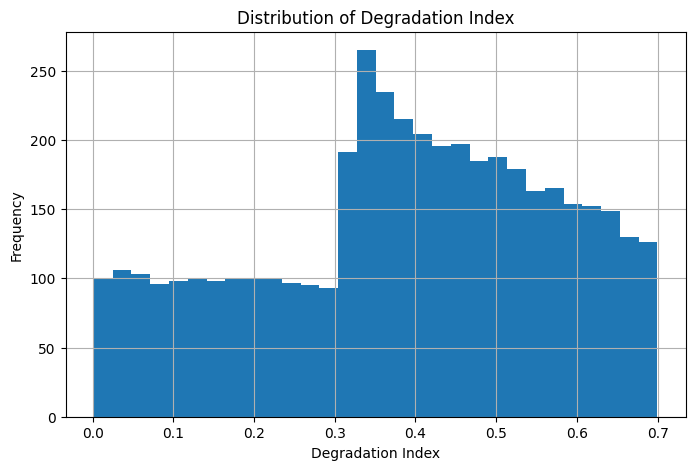

In [23]:
#Degradation Index Distribution
plt.figure(figsize=(8,5))

plt.hist(
    fleet_df["degradation_index"],
    bins=30
)

plt.title("Distribution of Degradation Index")
plt.xlabel("Degradation Index")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

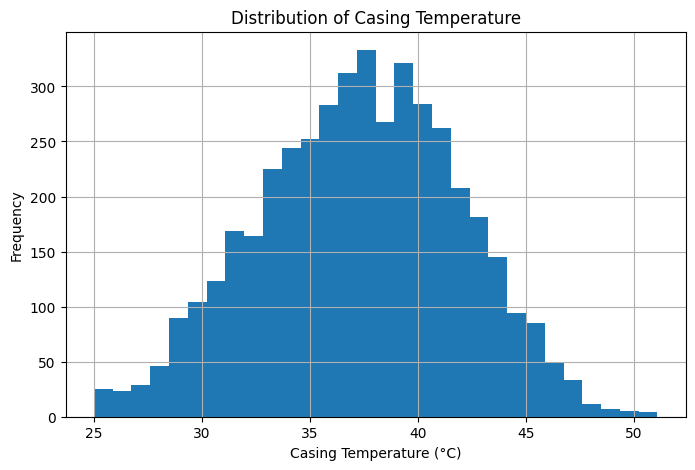

In [24]:
#temperature distribution
plt.figure(figsize=(8,5))
plt.hist(
    fleet_df["casing_temperature_c"],
    bins=30
)
plt.title("Distribution of Casing Temperature")
plt.xlabel("Casing Temperature (°C)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

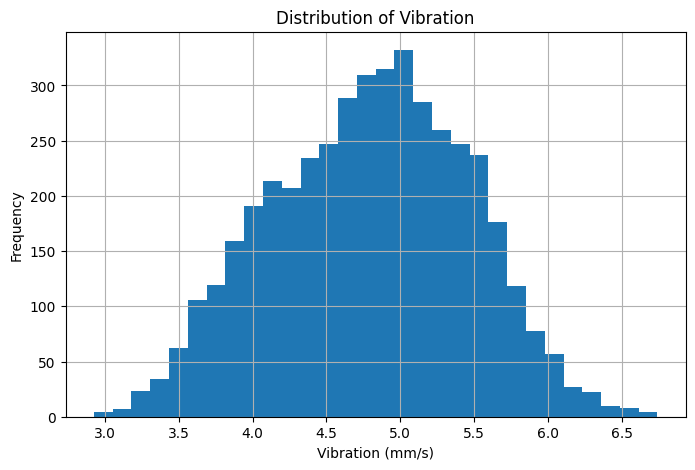

In [25]:
#Vibration distribution
plt.figure(figsize=(8,5))
plt.hist(
    fleet_df["vibration_mm_s"],
    bins=30
)
plt.title("Distribution of Vibration")
plt.xlabel("Vibration (mm/s)")  
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

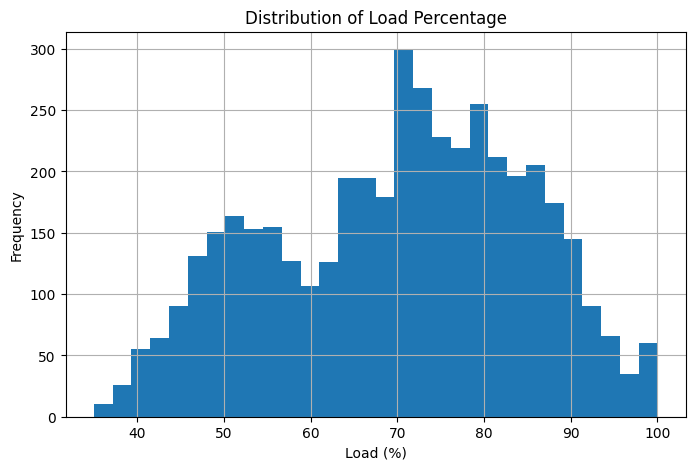

In [26]:
#Load distribution
plt.figure(figsize=(8,5))

plt.hist(
    fleet_df["daily_load_percent"],
    bins=30
)
plt.title("Distribution of Load Percentage")
plt.xlabel("Load (%)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

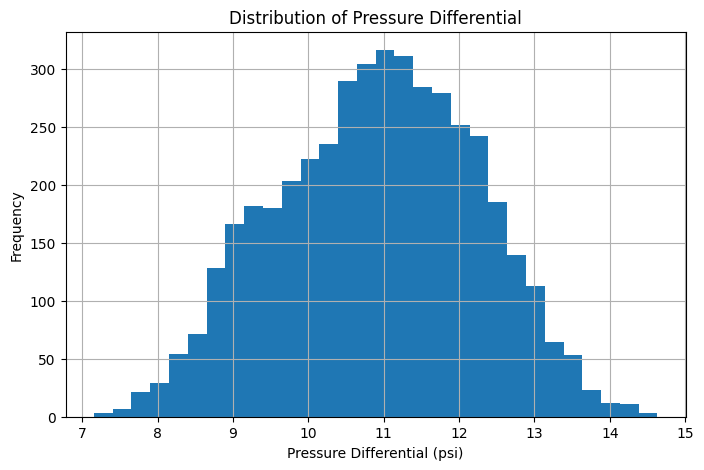

In [27]:
#Pressure distribution
plt.figure(figsize=(8,5))

plt.hist(
    fleet_df["pressure_diff_psi"],
    bins=30
)
plt.title("Distribution of Pressure Differential")
plt.xlabel("Pressure Differential (psi)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

TIME-SERIES ANALYSIS

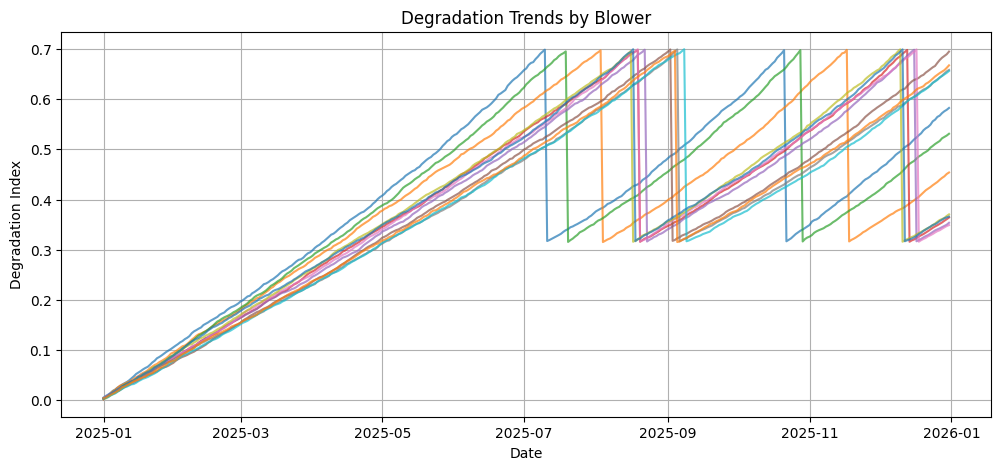

In [28]:
#degradation over time
plt.figure(figsize=(12,5))

for blower in fleet_df["blower_id"].unique():
    subset = fleet_df[
        fleet_df["blower_id"] == blower
    ]
    plt.plot(
        subset["date"],
        subset["degradation_index"],
        alpha=0.7
    )
plt.title("Degradation Trends by Blower")
plt.xlabel("Date")
plt.ylabel("Degradation Index")
plt.grid(True)
plt.show()

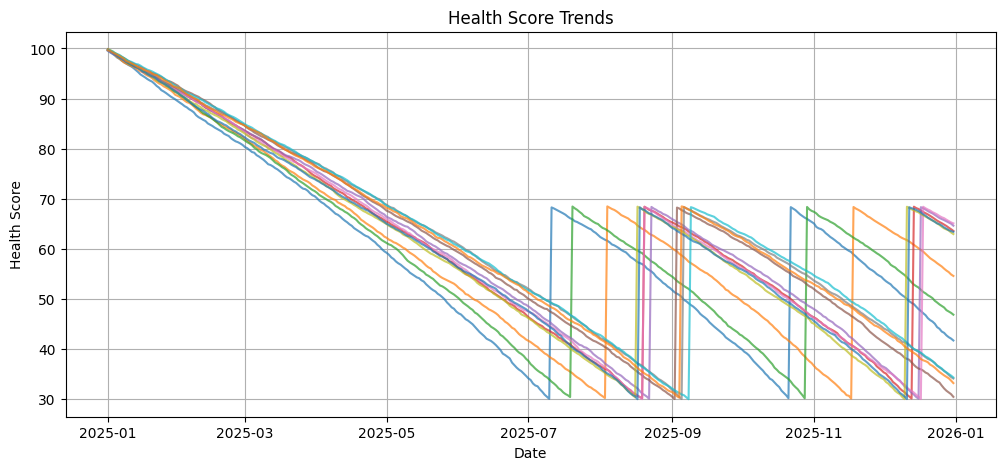

In [29]:
#Health score over time
plt.figure(figsize=(12,5))

for blower in fleet_df["blower_id"].unique():
    subset = fleet_df[
        fleet_df["blower_id"] == blower
    ]
    plt.plot(
        subset["date"],
        subset["health_score"],
        alpha=0.7
    )
plt.title("Health Score Trends")
plt.xlabel("Date")
plt.ylabel("Health Score")
plt.grid(True)
plt.show()

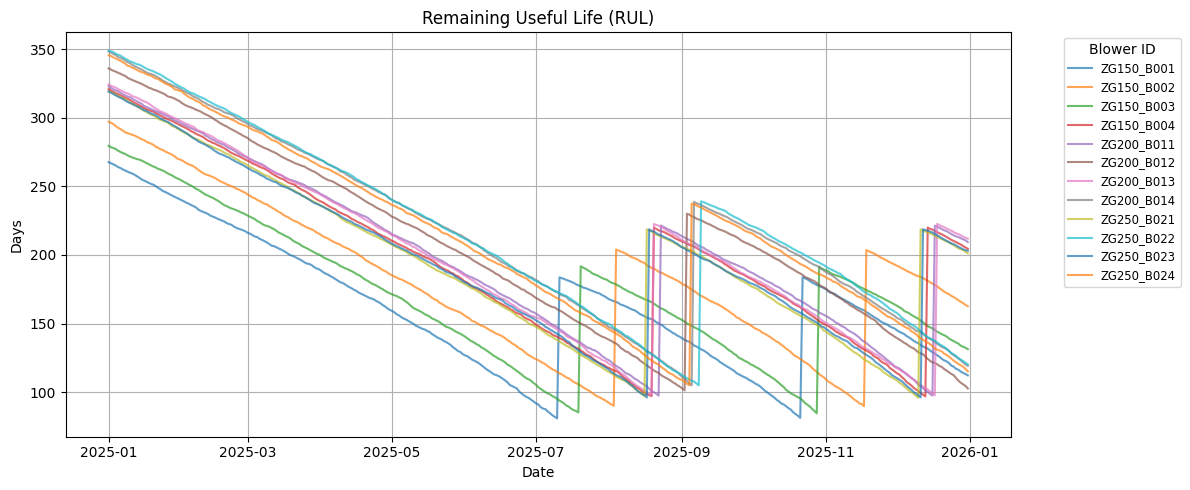

In [30]:
#RUL over time
plt.figure(figsize=(12,5))

for blower in fleet_df["blower_id"].unique():
    subset = fleet_df[fleet_df["blower_id"] == blower].sort_values("date")
    plt.plot(
        subset["date"],
        subset["RUL_days"],
        alpha=0.7,
        label=str(blower)
    )
plt.title("Remaining Useful Life (RUL)")
plt.xlabel("Date")
plt.ylabel("Days")
plt.legend(title="Blower ID", fontsize="small", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

SITE COMPARISONS

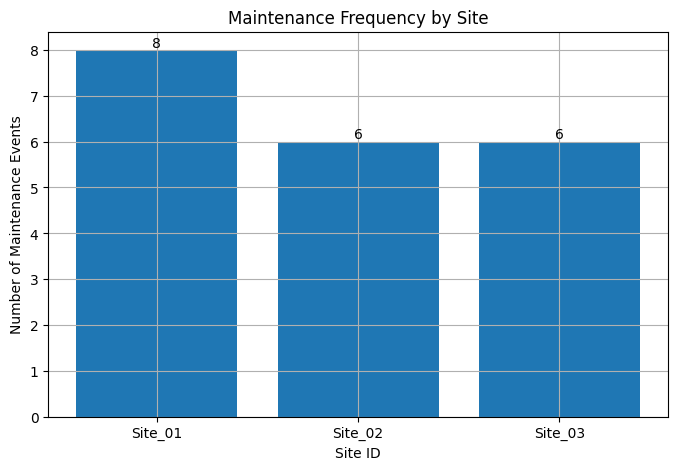

In [31]:
#Maintenance frequency by site
site_maintenance = (
    fleet_df.groupby("site_id")["maintenance_event"]
    .sum()
)


#histogram of maintenance frequency by site
plt.figure(figsize=(8,5))
plt.bar(site_maintenance.index, site_maintenance.values)
ax = plt.gca()
ax.bar_label(ax.containers[0], label_type='edge')
plt.title("Maintenance Frequency by Site")
plt.xlabel("Site ID")
plt.ylabel("Number of Maintenance Events")
plt.grid(True)
plt.show()

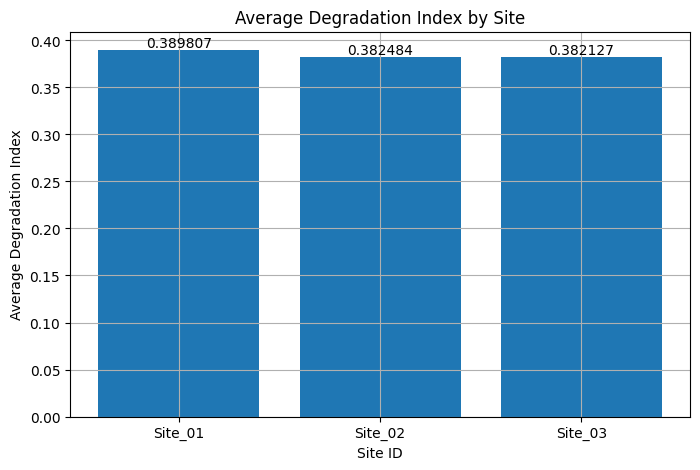

In [32]:
site_degradation = (
    fleet_df.groupby("site_id")["degradation_index"]
    .mean()
)

#histogram of average degradation index by site
plt.figure(figsize=(8,5))
plt.bar(site_degradation.index, site_degradation.values)
ax = plt.gca()
ax.bar_label(ax.containers[0], label_type='edge')
plt.title("Average Degradation Index by Site")
plt.xlabel("Site ID")
plt.ylabel("Average Degradation Index")
plt.grid(True)
plt.show()

OPERATIONAL CLASS COMPARISON

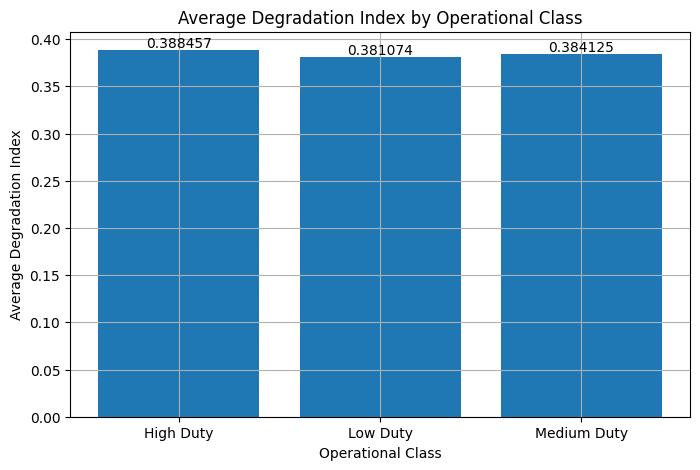

In [33]:
#Average degradation by operational class
class_degradation = (
    fleet_df.groupby("operational_class")["degradation_index"]
    .mean()
)

plt.figure(figsize=(8,5))
plt.bar(class_degradation.index, class_degradation.values)
ax = plt.gca()
ax.bar_label(ax.containers[0], label_type='edge')
plt.title("Average Degradation Index by Operational Class")
plt.xlabel("Operational Class")
plt.ylabel("Average Degradation Index")
plt.grid(True)
plt.show()

Correlation matrix

In [34]:
from pandas.io.formats.style import Styler

correlation_columns = [
    "amb_temp_avg_c",
    "humidity",
    "dust_index",
    "daily_op_hours",
    "daily_load_percent",
    "pressure_diff_psi",
    "casing_temperature_c",
    "vibration_mm_s",
    "degradation_index",
    "daily_degradation",
    "health_score",
    "RUL_days"
]

correlation_matrix = (
    fleet_df[correlation_columns]
    .corr()
)

correlation_matrix.style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1)

,amb_temp_avg_c,humidity,dust_index,daily_op_hours,daily_load_percent,pressure_diff_psi,casing_temperature_c,vibration_mm_s,degradation_index,daily_degradation,health_score,RUL_days
amb_temp_avg_c,1.000000,-0.011435,0.063662,-0.004783,-0.006386,0.010422,0.781890,-0.011251,-0.452822,-0.035647,0.452822,0.432182
humidity,-0.011435,1.000000,-0.454525,-0.002336,0.000495,-0.111049,-0.028635,-0.067813,-0.371015,-0.112132,0.371015,0.354041
dust_index,0.063662,-0.454525,1.000000,-0.003451,0.004086,0.259224,0.098152,0.105958,0.200236,0.108177,-0.200236,-0.191701
daily_op_hours,-0.004783,-0.002336,-0.003451,1.000000,0.854581,0.762406,0.447505,0.745735,0.012296,0.145887,-0.012296,-0.148764
daily_load_percent,-0.006386,0.000495,0.004086,0.854581,1.000000,0.892535,0.522658,0.853766,0.010393,0.187496,-0.010393,-0.136695
pressure_diff_psi,0.010422,-0.111049,0.259224,0.762406,0.892535,1.000000,0.512800,0.819127,0.053582,0.204352,-0.053582,-0.163090
casing_temperature_c,0.781890,-0.028635,0.098152,0.447505,0.522658,0.512800,1.000000,0.448361,-0.345319,0.087190,0.345319,0.265903
vibration_mm_s,-0.011251,-0.067813,0.105958,0.745735,0.853766,0.819127,0.448361,1.000000,0.166761,0.260561,-0.166761,-0.270310
degradation_index,-0.452822,-0.371015,0.200236,0.012296,0.010393,0.053582,-0.345319,0.166761,1.000000,0.346236,-1.000000,-0.965929
daily_degradation,-0.035647,-0.112132,0.108177,0.145887,0.187496,0.204352,0.087190,0.260561,0.346236,1.000000,-0.346236,-0.398111


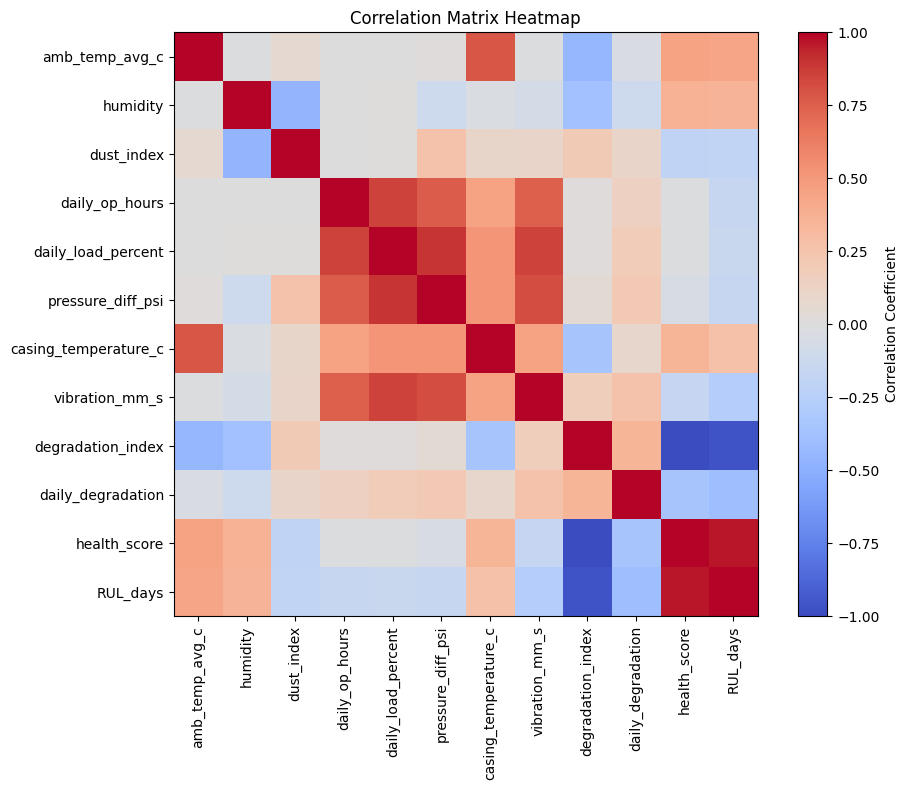

In [35]:
correlation_matrix["degradation_index"]\
    .sort_values(ascending=False)

#plot correlation matrix as heatmap
plt.figure(figsize=(10,8))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation Coefficient")   
plt.xticks(range(len(correlation_columns)), correlation_columns, rotation=90)
plt.yticks(range(len(correlation_columns)), correlation_columns)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

In [37]:
fig.savefig(
    BASE_DIR / "outputs" / "final_figures" / "degradation_trends.png",
    dpi=300,
    bbox_inches="tight"
)

NameError: name 'fig' is not defined